[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/pytorch-mastery/blob/main/06_end_to_end_projects/recommendation_system/recommendation_system.ipynb)


# 04 . Recommendation System: Two-Tower Retrieval with In-Batch Negatives

## Concept — Two-tower retrieval (revision notes)

**What it is**
- Learn one network that maps a **user** to a vector and another that maps an **item** to a vector,
  so that a user's vector is close to the vectors of items they interact with.
- Retrieval = nearest neighbours among item vectors, which can be precomputed and indexed.

**Why it matters**
- It is the first stage of most large recommenders: score millions of items cheaply (a dot product),
  then rerank a few hundred with a heavier model.
- Training uses only positives (clicks); negatives come for free from the *other items in the same batch*.
  Doing this correctly (duplicates, popularity bias) is where most of the quality comes from.

**When to use**
- Large catalogues, implicit feedback (clicks, plays), need low-latency serving.
- If you have few items, a ranking model that sees user and item features together may be better.

**Math & intuition**
- Score `s(u,i) = <f(u), g(i)>` with unit-norm vectors (cosine) divided by a temperature `tau`.
- In-batch softmax: for a batch of positive pairs `(u_b, i_b)`, row `b` of the `B x B` logit matrix
  has its positive on the diagonal; the loss is cross-entropy with target `b`. Initial loss is about `ln B`.
- Popular items appear more often in batches, so they are over-used as negatives. **logQ correction**
  subtracts `log q(i)` (sampling probability) from the logits to undo that bias.
- Metric: `recall@k` = fraction of a user's held-out items that appear in the top-k (excluding items already seen).

### 1. Setup and imports

**What this cell does (plain language):** makes the project folder importable and imports the data generator, the two-tower model, the loss and the evaluation code. Everything runs on CPU in seconds.

In [1]:
import os, sys, subprocess
# The notebook imports a small tested module that lives next to it.
# On Colab that folder is not there yet, so fetch the repo once and move into the project directory.
PROJECT = "06_end_to_end_projects/recommendation_system"
if not os.path.exists("data.py"):
    if not os.path.exists("PyTorch-Mastery"):
        subprocess.run(["git", "clone", "-q", "https://github.com/himanshu231204/PyTorch-Mastery"], check=False)
    if os.path.isdir("PyTorch-Mastery/" + PROJECT):
        os.chdir("PyTorch-Mastery/" + PROJECT)
sys.path.insert(0, os.getcwd())

import torch, torch.nn.functional as F
import matplotlib.pyplot as plt
from data import make_interactions, leave_k_out, train_batches
from model import TwoTower, recall_at_k, popularity_scores, _recall_from_scores
from train import in_batch_softmax_loss, fit

torch.manual_seed(0)
print("torch", torch.__version__)

torch 2.14.1+cu130


### 2. Generate synthetic user-item interactions

**What this cell does (plain language):** builds a hidden world: 300 users and 200 items in 5 taste groups with latent vectors plus a per-item popularity bias; each user then 'clicks' 25 distinct items sampled by softmax affinity. Because we generated the data we know the truth (taste groups), which lets us sanity-check the recommender later.

interactions: 7500 | users: 300 | items: 200
matrix density: 0.125  (sparse: most user-item pairs are unobserved, NOT negative)
clicks of the 5 most / least popular items: [129, 125, 118, 102, 93] [5, 4, 3, 2, 1]


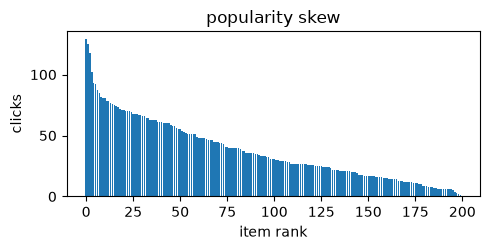

In [2]:
data = make_interactions(n_users=300, n_items=200, n_groups=5, per_user=25, seed=0)
pairs, n_users, n_items = data["pairs"], data["n_users"], data["n_items"]
print("interactions:", len(pairs), "| users:", n_users, "| items:", n_items)
density = len(pairs) / (n_users * n_items)
print(f"matrix density: {density:.3f}  (sparse: most user-item pairs are unobserved, NOT negative)")
counts = torch.bincount(pairs[:, 1], minlength=n_items).sort(descending=True).values
print("clicks of the 5 most / least popular items:", counts[:5].tolist(), counts[-5:].tolist())
plt.figure(figsize=(5, 2.6)); plt.bar(range(n_items), counts); plt.xlabel("item rank"); plt.ylabel("clicks"); plt.title("popularity skew"); plt.tight_layout(); plt.show()

### 3. Split: hold out 3 positives per user

**What this cell does (plain language):** for each user we hide 3 random clicks as the test set and train on the rest. At evaluation time we rank all items and check whether the hidden ones show up. We verify the two sets are disjoint - leaking test clicks into training is the classic recommender bug.

In [3]:
train_pairs, test_pairs = leave_k_out(pairs, n_users, k=3, seed=0)
print("train:", len(train_pairs), "test:", len(test_pairs))
overlap = set(map(tuple, train_pairs.tolist())) & set(map(tuple, test_pairs.tolist()))
print("overlap between train and test:", len(overlap))

train: 6600 test: 900
overlap between train and test: 0


### 4. Metric sanity checks and baselines

**What this cell does (plain language):** before training anything we compute recall@10 for a random scorer and a most-popular scorer, and verify the metric gives 1.0 for a perfect scorer. The popularity baseline is strong on skewed data, so any learned model must beat it to be worth its complexity.

In [4]:
k = 10
rand_scores = torch.rand(n_users, n_items)
perfect = torch.zeros(n_users, n_items); perfect[test_pairs[:, 0], test_pairs[:, 1]] = 1.0
pop_scores = popularity_scores(train_pairs, n_users, n_items)
r_rand = _recall_from_scores(rand_scores, train_pairs, test_pairs, n_users, k)
r_pop = _recall_from_scores(pop_scores, train_pairs, test_pairs, n_users, k)
print(f"perfect scorer recall@{k}: {_recall_from_scores(perfect, train_pairs, test_pairs, n_users, k):.3f}")
print(f"random  scorer recall@{k}: {r_rand:.3f}   (about k / unseen items = {k / (n_items - 22):.3f})")
print(f"popular scorer recall@{k}: {r_pop:.3f}")

perfect scorer recall@10: 1.000
random  scorer recall@10: 0.060   (about k / unseen items = 0.056)
popular scorer recall@10: 0.152


### 5. Build the two towers

**What this cell does (plain language):** each tower is an ID embedding (items also get their taste-group as a side feature) followed by an MLP and L2 normalisation. We check output shapes and confirm all vectors have unit length, so a dot product equals cosine similarity.

In [5]:
torch.manual_seed(0)
model = TwoTower(n_users, n_items, data["item_group"], n_groups=5, emb=16, out=16)
u = torch.tensor([0, 1, 2]); i = torch.tensor([5, 6, 7])
uv, iv = model.user_vec(u), model.item_vec(i)
print("user vectors:", tuple(uv.shape), "item vectors:", tuple(iv.shape))
print("norms:", uv.norm(dim=-1).tolist(), iv.norm(dim=-1).tolist())
print("parameters:", sum(p.numel() for p in model.parameters()))

user vectors: (3, 16) item vectors: (3, 16)
norms: [1.0, 1.0000001192092896, 0.9999999403953552] [1.0, 1.0, 0.9999999403953552]
parameters: 10736


### 6. In-batch negatives, step by step

**What this cell does (plain language):** takes one batch of 8 (user, item) positives and builds the 8x8 logit matrix. Entry (r, c) is how much user r likes the item that user c clicked. The diagonal holds the true pairs; the off-diagonal items act as negatives. At initialisation the model cannot tell positives from negatives, so the loss is near `ln 8 = 2.08` if all scores are similar; with temperature 0.1 even random cosines are spread out, so expect a somewhat larger value.

In [6]:
g = torch.Generator().manual_seed(0)
u_b, i_b = next(train_batches(train_pairs, 8, g))
logits = model.user_vec(u_b) @ model.item_vec(i_b).T / 0.1
print("logit matrix shape:", tuple(logits.shape))
print("diagonal (positives):", [round(x, 2) for x in logits.diag().tolist()])
print(f"loss at init {in_batch_softmax_loss(model.user_vec(u_b), model.item_vec(i_b), i_b):.3f} (ln 8 = {torch.log(torch.tensor(8.0)):.3f})")

logit matrix shape: (8, 8)
diagonal (positives): [0.2, 0.39, -0.47, 1.15, -0.56, -1.0, -2.12, -1.68]
loss at init 3.100 (ln 8 = 2.079)


### 7. False negatives: the same item twice in a batch

**What this cell does (plain language):** if two users in the batch clicked the SAME item, the second copy would be treated as a negative for the first user even though it is a true positive. Our loss masks those entries to -inf. Here we force a batch with duplicates and compare the loss with and without the mask.

In [7]:
torch.manual_seed(0)
uvec = F.normalize(torch.randn(4, 16), dim=-1)
ivec = F.normalize(torch.randn(4, 16), dim=-1)
items = torch.tensor([3, 3, 7, 9])                   # item 3 appears twice ...
ivec[1] = ivec[0]                                    # ... so both rows share the same item vector
uvec[0] = uvec[1] = ivec[0]                          # and both users are perfectly aligned with it
masked = in_batch_softmax_loss(uvec, ivec, items)
naive = F.cross_entropy(uvec @ ivec.T / 0.1, torch.arange(4))      # no masking
print(f"masked loss {masked:.4f} | naive loss {naive:.4f}")
print("the naive loss is larger: for the two affected rows the duplicate (a TRUE positive) ties with the real positive and is counted as a negative")

masked loss 1.6783 | naive loss 2.0249
the naive loss is larger: for the two affected rows the duplicate (a TRUE positive) ties with the real positive and is counted as a negative


### 8. Train with plain in-batch negatives

**What this cell does (plain language):** trains for 15 epochs with Adam, batch size 128, temperature 0.1. After each epoch we compute recall@10 on the held-out clicks. The loss floor is high because with 128 candidates and noisy click data, you cannot predict clicks perfectly.

In [8]:
torch.manual_seed(0)
m_plain = TwoTower(n_users, n_items, data["item_group"], n_groups=5)
h_plain = fit(m_plain, train_pairs, test_pairs, n_users, epochs=15, bs=128, lr=5e-3, temperature=0.1, logq=False)

epoch  1 | loss 4.890 | recall@10 0.198
epoch  2 | loss 4.385 | recall@10 0.333
epoch  3 | loss 4.087 | recall@10 0.337


epoch  4 | loss 4.025 | recall@10 0.340
epoch  5 | loss 4.002 | recall@10 0.337
epoch  6 | loss 3.978 | recall@10 0.333


epoch  7 | loss 3.975 | recall@10 0.340
epoch  8 | loss 3.953 | recall@10 0.322


epoch  9 | loss 3.951 | recall@10 0.338
epoch 10 | loss 3.934 | recall@10 0.326


epoch 11 | loss 3.936 | recall@10 0.336
epoch 12 | loss 3.929 | recall@10 0.343


epoch 13 | loss 3.921 | recall@10 0.326
epoch 14 | loss 3.914 | recall@10 0.331


epoch 15 | loss 3.906 | recall@10 0.322


### 9. Train with logQ correction

**What this cell does (plain language):** repeats training but subtracts `log q(item)` from the logits, where `q` is each item's training frequency. This stops popular items being punished merely for appearing as negatives more often. We compare the two recall curves and the popularity baseline.

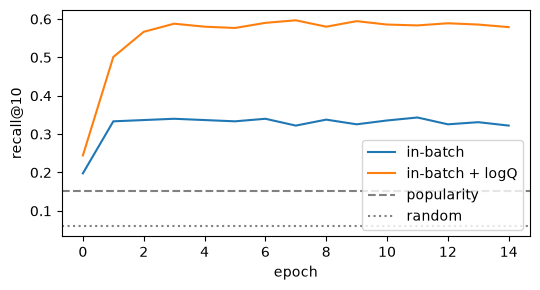

final recall@10: plain 0.322 | logQ 0.579 | popularity 0.152


In [9]:
torch.manual_seed(0)
m_logq = TwoTower(n_users, n_items, data["item_group"], n_groups=5)
h_logq = fit(m_logq, train_pairs, test_pairs, n_users, epochs=15, bs=128, lr=5e-3, temperature=0.1, logq=True, verbose=False)
plt.figure(figsize=(5.5, 3))
plt.plot([r for _, r in h_plain], label="in-batch")
plt.plot([r for _, r in h_logq], label="in-batch + logQ")
plt.axhline(r_pop, ls="--", c="gray", label="popularity"); plt.axhline(r_rand, ls=":", c="gray", label="random")
plt.xlabel("epoch"); plt.ylabel(f"recall@{k}"); plt.legend(); plt.tight_layout(); plt.show()
print(f"final recall@{k}: plain {h_plain[-1][1]:.3f} | logQ {h_logq[-1][1]:.3f} | popularity {r_pop:.3f}")

### 10. Ablation: does the item side feature help?

**What this cell does (plain language):** trains the same model with and without the taste-group embedding on the item tower. A pure ID-embedding tower must learn each item from its few interactions; a side feature lets items share statistical strength. Compare the epoch-3 numbers: the side feature mostly speeds up learning here, while by epoch 15 both can end up similar.

In [10]:
res = {}
for name, ng in (("ID only", 0), ("ID + group feature", 5)):
    torch.manual_seed(0)
    m = TwoTower(n_users, n_items, data["item_group"], n_groups=ng)
    h = fit(m, train_pairs, test_pairs, n_users, epochs=15, logq=True, verbose=False)
    res[name] = (h[2][1], h[-1][1])
for name, (early, final) in res.items():
    print(f"{name:20s} recall@{k} after epoch 3: {early:.3f} | after epoch 15: {final:.3f}")

ID only              recall@10 after epoch 3: 0.181 | after epoch 15: 0.579
ID + group feature   recall@10 after epoch 3: 0.567 | after epoch 15: 0.579


### 11. Sanity check against ground truth and look at recommendations

**What this cell does (plain language):** we know each user's hidden taste group, so we can measure how often the top-10 items for a user come from their own group. Random items would match about 1/5 of the time. This kind of check catches a model that scores well on recall only by recommending popular items.

In [11]:
m_logq.eval()
with torch.no_grad():
    scores = m_logq.user_vec(torch.arange(n_users)) @ m_logq.all_item_vecs().T
scores[train_pairs[:, 0], train_pairs[:, 1]] = float("-inf")
top = scores.topk(10, dim=1).indices
same_group = (data["item_group"][top] == data["user_group"][:, None]).float().mean().item()
print(f"fraction of top-10 items in the user's own taste group: {same_group:.3f} (random would be about 0.2)")
print("user 0 top-10 items:", top[0].tolist(), "| user 0 group:", data["user_group"][0].item())
print("their groups       :", data["item_group"][top[0]].tolist())

fraction of top-10 items in the user's own taste group: 0.754 (random would be about 0.2)
user 0 top-10 items: [127, 95, 62, 150, 66, 151, 70, 183, 84, 97] | user 0 group: 3
their groups       : [3, 3, 3, 3, 3, 3, 3, 3, 3, 3]


### 12. Serving: precompute item vectors, retrieve for a user

**What this cell does (plain language):** at serving time item vectors are computed once and stored in an index; only the user tower runs per request, followed by a top-k search. Brute-force matrix multiplication is exact and fine for thousands of items; for millions you would swap in an approximate index (FAISS, ScaNN). We time a request and show the optional FAISS import guarded.

In [12]:
import time
item_index = m_logq.all_item_vecs()                      # (n_items, 16) computed once, offline

def recommend(user_id, seen_items, topk=5):
    with torch.no_grad():
        q = m_logq.user_vec(torch.tensor([user_id]))     # one cheap forward pass per request
        s = (q @ item_index.T)[0]
    s[list(seen_items)] = float("-inf")
    return s.topk(topk).indices.tolist()

seen = train_pairs[train_pairs[:, 0] == 0][:, 1].tolist()
t = time.perf_counter(); recs = recommend(0, seen); ms = (time.perf_counter() - t) * 1000
print("recommendations for user 0:", recs, f"({ms:.2f} ms)")
try:
    import faiss
    print("faiss available: use faiss.IndexFlatIP for exact, IndexHNSWFlat for approximate search")
except ImportError:
    print("faiss not installed (optional). Install with: pip install faiss-cpu")

recommendations for user 0: [127, 95, 62, 150, 66] (0.32 ms)
faiss not installed (optional). Install with: pip install faiss-cpu


## Common bugs

- **Treating unobserved pairs as true negatives** — fix: missing interaction means unknown, not disliked; use sampled negatives and expect label noise.
- **False negatives in the batch** — fix: the same item can appear several times; mask equal item ids (as our loss does) or the model is told true positives are negatives.
- **Recommending items the user already has** — fix: mask training positives before top-k, or recall is inflated and recommendations are useless.
- **Popularity bias from in-batch sampling** — fix: popular items are over-sampled as negatives and under-ranked; apply logQ correction or sample negatives uniformly.
- **Forgetting to normalise vectors / ignoring temperature** — fix: unnormalised dot products explode; normalise and divide by a temperature around 0.05-0.2.
- **Leaking the test set** — fix: split per user BEFORE training and never use held-out clicks for item statistics such as popularity or logQ (we compute them from train_pairs only).
- **Evaluating with in-batch candidates** — fix: real retrieval ranks the whole catalogue; evaluating on a small candidate list overstates recall.
- **Batches with too few distinct items** — fix: tiny batches give few and easy negatives; use larger batches or a memory bank of past item vectors.

## Exercises

**Exercise 1.** Report recall@5 and recall@20 for `m_logq` (use `recall_at_k` with different k).

In [13]:
# Your attempt for Exercise 1 here

**Solution 1**

In [14]:
# Solution 1
for kk in (5, 20):
    print(kk, round(recall_at_k(m_logq, train_pairs, test_pairs, n_users, k=kk), 3))

5 0.41
20 0.726


**Exercise 2.** Train with temperatures 0.02, 0.1 and 1.0 and compare recall@10. What do you observe, and what does the temperature control in the softmax?

In [15]:
# Your attempt for Exercise 2 here

**Solution 2**

In [16]:
# Solution 2
for tau in (0.02, 0.1, 1.0):
    torch.manual_seed(0)
    mt = TwoTower(n_users, n_items, data["item_group"], n_groups=5)
    h = fit(mt, train_pairs, test_pairs, n_users, epochs=15, temperature=tau, logq=True, verbose=False)
    print("temperature", tau, "recall@10:", round(h[-1][1], 3))
# temperature scales cosine logits: small tau -> sharp softmax focused on the hardest negatives, large tau -> flat softmax.
# On this tiny, easy problem the differences may be small; compare the numbers you actually get.

temperature 0.02 recall@10: 0.589


temperature 0.1 recall@10: 0.579


temperature 1.0 recall@10: 0.567


**Exercise 3.** Compute catalogue coverage: how many distinct items appear in anyone's top-10 for `m_logq`? Compare to popularity.

In [17]:
# Your attempt for Exercise 3 here

**Solution 3**

In [18]:
# Solution 3
print("model coverage:", top.unique().numel(), "of", n_items)
pop_top = pop_scores.clone(); pop_top[train_pairs[:, 0], train_pairs[:, 1]] = float("-inf")
print("popularity coverage:", pop_top.topk(10, dim=1).indices.unique().numel())

model coverage: 162 of 200
popularity coverage: 18


**Exercise 4.** Find the 3 users with the lowest recall@10 and print their taste group sizes. Are cold users the problem?

In [19]:
# Your attempt for Exercise 4 here

**Solution 4**

In [20]:
# Solution 4
hits = torch.zeros(n_users); truth = torch.zeros(n_users, n_items, dtype=torch.bool)
truth[test_pairs[:, 0], test_pairs[:, 1]] = True
hits = truth.gather(1, top).sum(1)
print("worst users:", hits.argsort()[:3].tolist(), "hits:", hits[hits.argsort()[:3]].tolist())

worst users: [138, 79, 24] hits: [0, 0, 0]


**Exercise 5.** Replace the MLP towers with plain embeddings (matrix factorisation style): write `MFTower` that returns `F.normalize(self.emb(ids))` and train it.

In [21]:
# Your attempt for Exercise 5 here

**Solution 5**

In [22]:
# Solution 5
class MF(torch.nn.Module):
    def __init__(self, n_users, n_items, d=16):
        super().__init__(); self.u = torch.nn.Embedding(n_users, d); self.i = torch.nn.Embedding(n_items, d); self.n_items = n_items
        self.register_buffer("item_group", data["item_group"])
    def user_vec(self, x): return F.normalize(self.u(x), dim=-1)
    def item_vec(self, x): return F.normalize(self.i(x), dim=-1)
    def all_item_vecs(self): return self.item_vec(torch.arange(self.n_items))
torch.manual_seed(0); mf = MF(n_users, n_items)
h = fit(mf, train_pairs, test_pairs, n_users, epochs=15, logq=True, verbose=False); print("MF recall@10:", round(h[-1][1], 3))

MF recall@10: 0.196


**Exercise 6.** Implement hard-negative mining: for each batch also add the 10 highest-scoring non-positive items as extra negatives. Sketch the logit matrix shape.

In [23]:
# Your attempt for Exercise 6 here

**Solution 6**

In [24]:
# Solution 6
u_b, i_b = next(train_batches(train_pairs, 16, torch.Generator().manual_seed(1)))
with torch.no_grad():
    all_scores = m_logq.user_vec(u_b) @ item_index.T
hard = all_scores.topk(10, dim=1).indices                # (16, 10) candidate hard negatives
print("extra negatives per user:", tuple(hard.shape), "-> logits would be (16, 16 + 10)")
# in practice drop any hard negative that equals the user's positive items

extra negatives per user: (16, 10) -> logits would be (16, 16 + 10)
